In [2]:
print("Hii")

Hii


In [3]:

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
import xgboost as xgb
import pickle

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')

In [4]:

# Load Dataset

df = pd.read_csv('C:/Users/USER/Downloads/archive (1)/properties.csv')
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing Values:\n{df.isnull().sum().sort_values(ascending=False)}")

Dataset Shape: (203874, 26)

Columns: ['ad_title', 'ad_description', 'details', 'slug', 'title', 'type', 'price', 'timestamp', 'posted_date', 'deactivation_date', 'category', 'parent_category', 'location', 'geo_region', 'area', 'is_delivery_free', 'is_doorstep_delivery', 'is_dsd_applicable', 'is_member', 'is_authorized_dealer', 'is_featured_member', 'is_verified', 'membership_level', 'member_since', 'properties', 'user']

Missing Values:
member_since            26459
is_authorized_dealer     4462
is_featured_member       4462
is_member                4462
price                    1562
details                  1527
deactivation_date           6
posted_date                 6
timestamp                   6
ad_description              2
title                       0
slug                        0
type                        0
ad_title                    0
category                    0
parent_category             0
location                    0
geo_region                  0
is_dsd_applicable 

In [5]:

#Initial Data Overview

print("First 5 rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nPrice Statistics:")
print(df['price'].describe())

print("\nProperty Types Distribution:")
print(df['type'].value_counts())

First 5 rows:


,ad_title,ad_description,details,slug,title,type,price,timestamp,posted_date,deactivation_date,category,parent_category,location,geo_region,area,is_delivery_free,is_doorstep_delivery,is_dsd_applicable,is_member,is_authorized_dealer,is_featured_member,is_verified,membership_level,member_since,properties,user
0,apartment for sale in colombo 05 | ikman,Project: Aquaria by Access Residencies.\n\nSq....,"Bedrooms: 3, Bathrooms: 2",apartment-for-sale-in-colombo-05-for-sale-colo...,apartment for sale in colombo 05,for_sale,"Rs 59,500,000",16 Feb 2:38 pm,2023-02-16T14:38:34+05:30,2022-01-31T04:43:32.000Z,Apartments For Sale,Property,Colombo 5,LK-11,"{'id': 1506, 'name': 'Colombo'}",False,False,False,True,False,False,True,plus,October 2016,"{'Address': 'kirimandala mawatha, colombo 05.'...",2a36021370cdd0f50da19f64d17ad43be687d48568ec12...
1,Land for Sale in Kurunegala | ikman.lk,à·à·à¶à·âà¶»à¶ºà·à¶±à· à¶¯à·à¶ºà·à¶«...,15.0 perches,land-for-sale-in-kurunegala-for-sale-kurunegal...,Land for Sale in Kurunegala,for_sale,"Rs 50,000 per perch",10 Nov 12:06 pm,2022-11-10T12:06:19+05:30,2022-07-30T09:30:41.000Z,Land,Property,Kurunegala City,LK-61,"{'id': 1674, 'name': 'Kurunegala'}",False,False,False,True,False,False,False,premium,April 2017,"{'Address': 'kurunegala,malkaduwawa', 'Land ty...",f917ed789e936ada5530694ede4edde85fdb53f739c5f6...
2,Land for Sale in Kelaniya | ikman,Good Residential Bare Land in Kelaniya\nLocate...,18.5 perches,land-for-sale-in-kelaniya-for-sale-gampaha-766,Land for Sale in Kelaniya,for_sale,"Rs 1,600,000 per perch",30 Jan 8:54 am,2023-01-30T08:54:35+05:30,2022-07-30T09:31:26.000Z,Land For Sale,Property,Kelaniya,LK-12,"{'id': 1577, 'name': 'Gampaha'}",False,False,False,True,False,False,True,premium,August 2016,"{'Address': 'Dalugama, Kelaniya', 'Land type':...",147c45b684bfeae3e3ffb0397b126d4e67392ad600e254...
3,Land for Sale in Kelaniya | ikman,Good Residential bare land in Kelaniya\nLocate...,12.0 perches,land-for-sale-in-kelaniya-for-sale-gampaha-765,Land for Sale in Kelaniya,for_sale,"Rs 1,700,000 per perch",30 Jan 8:54 am,2023-01-30T08:54:29+05:30,2022-07-30T09:24:20.000Z,Land For Sale,Property,Kelaniya,LK-12,"{'id': 1577, 'name': 'Gampaha'}",False,False,False,True,False,False,True,premium,August 2016,"{'Address': 'Off Kohalwila Road, Dalugama - Ke...",147c45b684bfeae3e3ffb0397b126d4e67392ad600e254...
4,Semi Luxury House for Sale in Kadawatha | ikman,Semi Luxury House in Kadawatha\nLocated at Pin...,"Bedrooms: 5, Bathrooms: 4",semi-luxury-house-for-sale-in-kadawatha-for-sa...,Semi Luxury House for Sale in Kadawatha,for_sale,"Rs 55,000,000",30 Jan 8:54 am,2023-01-30T08:54:09+05:30,2021-10-03T08:33:36.000Z,Houses For Sale,Property,Kadawatha,LK-12,"{'id': 1577, 'name': 'Gampaha'}",False,False,False,True,False,False,True,premium,August 2016,"{'Address': 'Pinthaliya Road, Kadawatha', 'Bed...",147c45b684bfeae3e3ffb0397b126d4e67392ad600e254...



Data Types:
ad_title                   str
ad_description             str
details                    str
slug                       str
title                      str
type                       str
price                      str
timestamp                  str
posted_date                str
deactivation_date          str
category                   str
parent_category            str
location                   str
geo_region                 str
area                       str
is_delivery_free          bool
is_doorstep_delivery      bool
is_dsd_applicable         bool
is_member               object
is_authorized_dealer    object
is_featured_member      object
is_verified               bool
membership_level           str
member_since               str
properties                 str
user                       str
dtype: object

Price Statistics:
count                   202312
unique                    6286
top       Rs 550,000 per perch
freq                      2830
Name: price, dtype: obje

In [6]:
# ============================================
# Cell 4: Parse 'properties' Column
# ============================================
import json

def parse_properties(prop_str):
    """Extract features from properties JSON/dict string"""
    if pd.isna(prop_str):
        return {}
    try:
        if isinstance(prop_str, str):
            # Replace single quotes with double quotes for valid JSON
            prop_dict = json.loads(prop_str.replace("'", '"'))
        else:
            prop_dict = prop_str
        return prop_dict
    except:
        return {}

# Parse properties into separate dataframe
props_df = df['properties'].apply(parse_properties).apply(pd.Series)

# Display extracted columns
print("Extracted Property Features:")
print(props_df.columns.tolist())
print(f"\nShape: {props_df.shape}")

# Display first few rows
display(props_df.head(10))

# Check missing values in parsed properties
print("\nMissing Values in Property Features:")
print(props_df.isnull().sum())

Extracted Property Features:
['Address', 'Bedrooms', 'Bathrooms', 'Size', 'Land type', 'Land size', 'House size', 'Beds', 'Baths', 'Property type', 'Features']

Shape: (203874, 11)


,Address,Bedrooms,Bathrooms,Size,Land type,Land size,House size,Beds,Baths,Property type,Features
0,"kirimandala mawatha, colombo 05.",3,2,"1,363 sqft",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"kurunegala,malkaduwawa",NaN,NaN,NaN,"Commercial, Residential",15.0 perches,NaN,NaN,NaN,NaN,NaN
2,"Dalugama, Kelaniya",NaN,NaN,NaN,"Residential, Other",18.5 perches,NaN,NaN,NaN,NaN,NaN
3,"Off Kohalwila Road, Dalugama - Kelaniya",NaN,NaN,NaN,"Residential, Other",12.0 perches,NaN,NaN,NaN,NaN,NaN
4,"Pinthaliya Road, Kadawatha",5,4,NaN,NaN,27.5 perches,"3,000.0 sqft",NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Emperor,NaN,NaN,"1,600 sqft",NaN,NaN,NaN,3,3,NaN,NaN
9,kadawatha Road,4,4,NaN,NaN,8.75 perches,"3,000.0 sqft",NaN,NaN,NaN,NaN



Missing Values in Property Features:
Address           62109
Bedrooms         150149
Bathrooms        150149
Size             184755
Land type        117777
Land size         54863
House size       140960
Beds             175849
Baths            175849
Property type    190383
Features         200330
dtype: int64


In [8]:
# Data Cleaning & Feature Engineering

import re

# Create a clean copy
df_clean = df.copy()

# Parse properties and merge
props_parsed = df_clean['properties'].apply(parse_properties).apply(pd.Series)

# Select useful columns from parsed properties
property_features = ['Bedrooms', 'Bathrooms', 'Beds', 'Baths',
                     'Land size', 'House size', 'Size', 'Land type',
                     'Property type', 'Features']

available_prop_cols = [col for col in property_features if col in props_parsed.columns]
props_parsed = props_parsed[available_prop_cols]

# Merge with main dataframe
df_clean = pd.concat([df_clean, props_parsed], axis=1)

print(f"Dataset shape after merge: {df_clean.shape}")

# ============================================
# Extract Numerical Values
# ============================================

def extract_number(text):
    """Extract first number from text like '3' or '1,363 sqft' or '15.0 perches'"""
    if pd.isna(text):
        return np.nan
    if isinstance(text, (int, float)):
        return float(text)
    match = re.search(r'[\d,]+\.?\d*', str(text))
    if match:
        return float(match.group().replace(',', ''))
    return np.nan

# Clean numerical columns
df_clean['bedrooms'] = df_clean['Bedrooms'].apply(extract_number)
df_clean['bathrooms'] = df_clean['Bathrooms'].apply(extract_number)
df_clean['beds'] = df_clean['Beds'].apply(extract_number)
df_clean['baths'] = df_clean['Baths'].apply(extract_number)
df_clean['land_size_raw'] = df_clean['Land size'].apply(extract_number)
df_clean['house_size_raw'] = df_clean['House size'].apply(extract_number)
df_clean['size_raw'] = df_clean['Size'].apply(extract_number)

# Combine bedroom/bathroom columns (use whichever has data)
df_clean['total_bedrooms'] = df_clean['bedrooms'].fillna(df_clean['beds'])
df_clean['total_bathrooms'] = df_clean['bathrooms'].fillna(df_clean['baths'])

# Combine size columns (priority: Size > House size > Land size)
df_clean['total_size'] = df_clean['size_raw'].fillna(df_clean['house_size_raw']).fillna(df_clean['land_size_raw'])

print("\n✅ Numerical features extracted")
print(f"   Bedrooms available: {df_clean['total_bedrooms'].notna().sum():,}")
print(f"   Bathrooms available: {df_clean['total_bathrooms'].notna().sum():,}")
print(f"   Size available: {df_clean['total_size'].notna().sum():,}")

# ============================================
# CLEAN PRICE COLUMN
# ============================================

def clean_price(price):
    """Convert any price format to float"""
    if pd.isna(price):
        return np.nan
    if isinstance(price, (int, float)):
        return float(price)
    # Remove currency symbols, commas, spaces - keep only digits and decimal
    price_str = re.sub(r'[^\d.]', '', str(price))
    try:
        return float(price_str)
    except:
        return np.nan

# Clean the price column
df_clean['price'] = df_clean['price'].apply(clean_price)

# Remove NaN prices
df_clean = df_clean.dropna(subset=['price'])

# Remove zero or negative prices
df_clean = df_clean[df_clean['price'] > 0]

# Remove extreme outliers (beyond 99th percentile)
price_99 = df_clean['price'].quantile(0.99)
price_1 = df_clean['price'].quantile(0.01)
df_clean = df_clean[(df_clean['price'] >= price_1) & (df_clean['price'] <= price_99)]

print(f"\nAfter cleaning price:")
print(f"  Min price: LKR {df_clean['price'].min():,.2f}")
print(f"  Max price: LKR {df_clean['price'].max():,.2f}")
print(f"  Median price: LKR {df_clean['price'].median():,.2f}")
print(f"  Records remaining: {len(df_clean):,}")

# ============================================
# Create Simple Features
# ============================================

# Has features indicator
df_clean['has_features'] = df_clean['Features'].notna().astype(int)

# Has land type indicator
df_clean['has_land_type'] = df_clean['Land type'].notna().astype(int)

# Property type grouping
df_clean['property_category'] = df_clean['Property type'].fillna('Unknown')

print("\n✅ New features created")
print(f"Final dataset: {df_clean.shape}")

Dataset shape after merge: (203874, 36)

✅ Numerical features extracted
   Bedrooms available: 81,750
   Bathrooms available: 81,750
   Size available: 168,130
Price column type: str
Sample price values: ['Rs 59,500,000', 'Rs 50,000 per perch', 'Rs 1,600,000 per perch', 'Rs 1,700,000 per perch', 'Rs 55,000,000', 'Rs 2,600,000 total price', 'Rs 4,700,000 total price', 'Rs 16,000,000 total price', 'Rs 700,000 /month', 'Rs 80,000,000']

After cleaning price:
  NaN values: 1,570
  Sample: [59500000.0, 50000.0, 1600000.0, 1700000.0, 55000000.0]

After removing price outliers:
  Min price: LKR 7,000.00
  Max price: LKR 200,000,000.00
  Median price: LKR 1,000,000.00
  Records remaining: 198,367


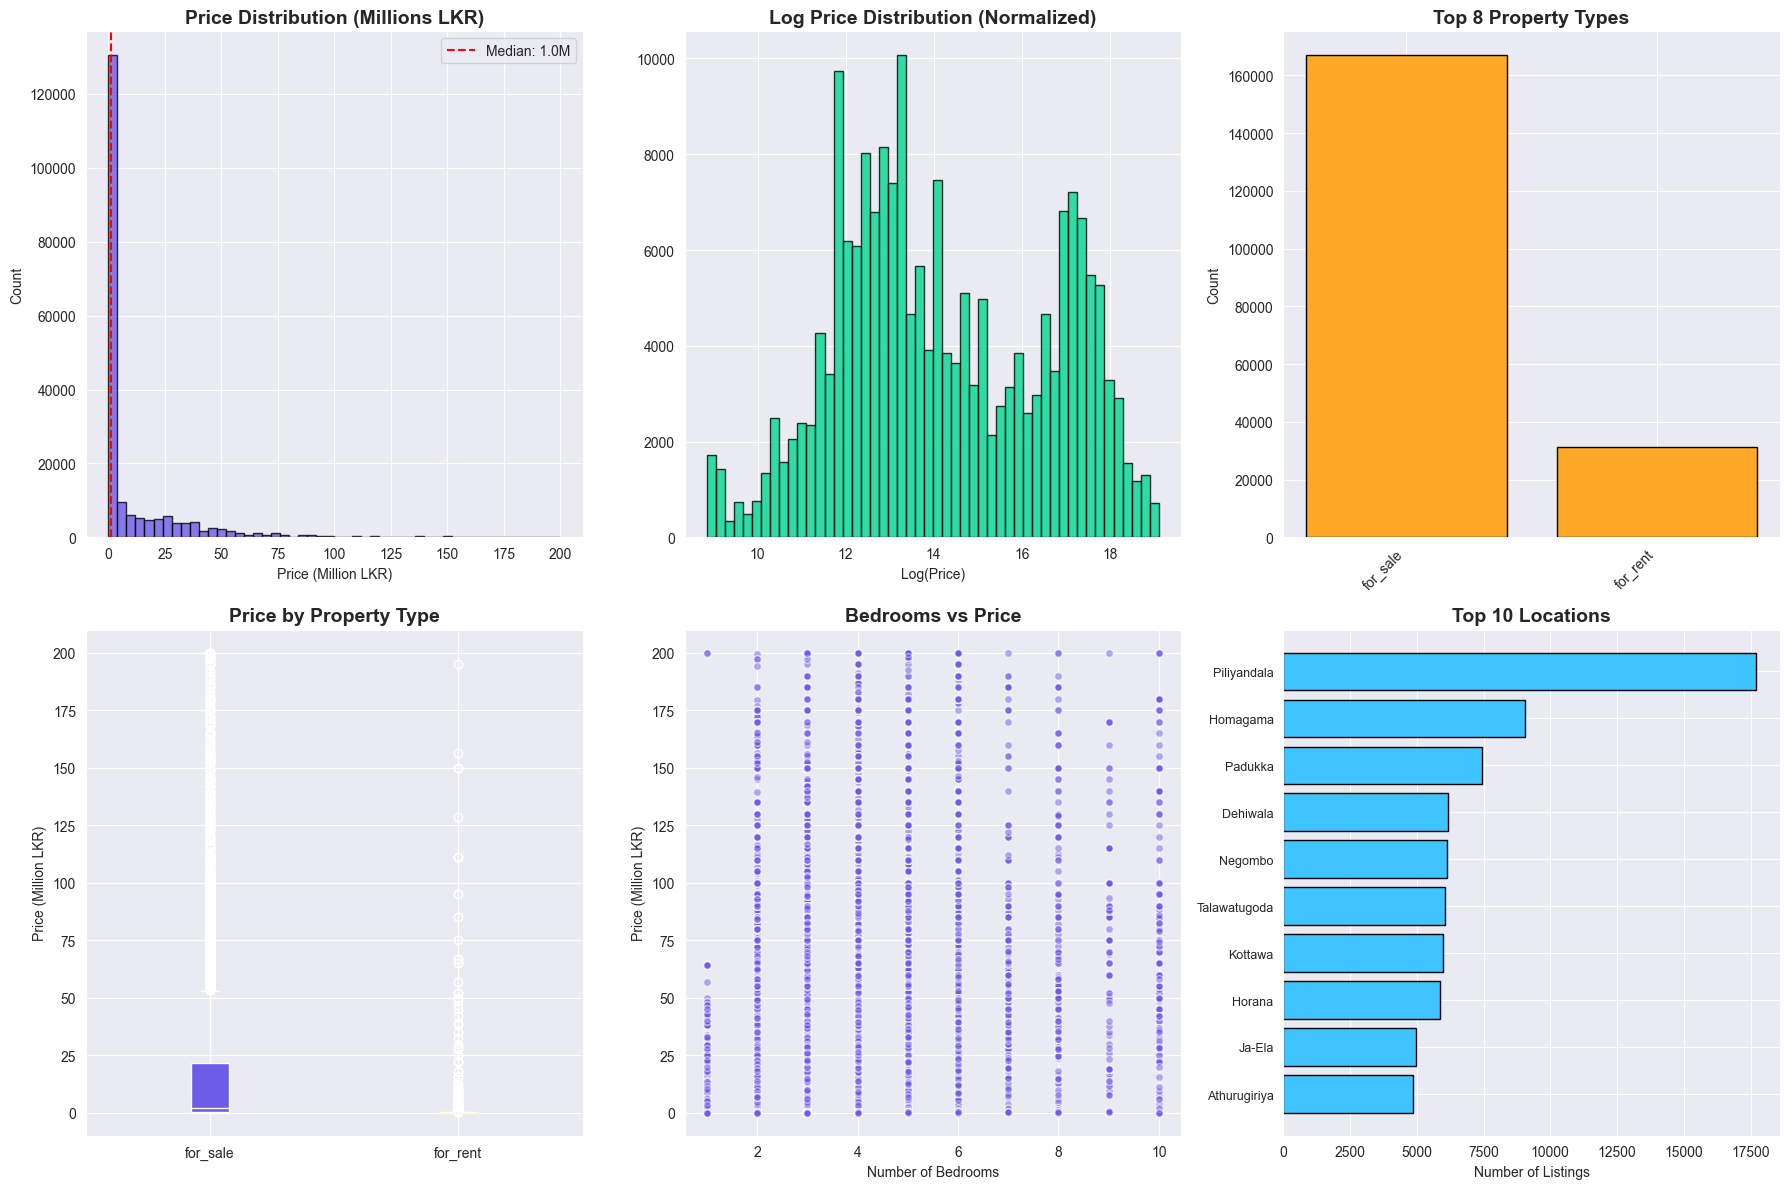


 Data Completeness Report:
  type                : ████████████████████ 100.0%
  location            : ████████████████████ 100.0%
  geo_region          : ████████████████████ 100.0%
  category            : ████████████████████ 100.0%
  total_bedrooms      : ███████░░░░░░░░░░░░░  39.7%
  total_bathrooms     : ███████░░░░░░░░░░░░░  39.7%
  total_size          : ████████████████░░░░  83.7%
  land_size_raw       : ██████████████░░░░░░  74.5%
  house_size_raw      : ██████░░░░░░░░░░░░░░  31.2%


In [10]:
# Exploratory Data Analysis

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Price Distribution
axes[0, 0].hist(df_clean['price'] / 1_000_000, bins=50, edgecolor='black', color='#6c5ce7', alpha=0.8)
axes[0, 0].set_title('Price Distribution (Millions LKR)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Price (Million LKR)')
axes[0, 0].set_ylabel('Count')
median_price = df_clean['price'].median() / 1_000_000
axes[0, 0].axvline(median_price, color='red', linestyle='--', label=f'Median: {median_price:.1f}M')
axes[0, 0].legend()

# 2. Log Price Distribution
axes[0, 1].hist(np.log1p(df_clean['price']), bins=50, edgecolor='black', color='#00d68f', alpha=0.8)
axes[0, 1].set_title('Log Price Distribution (Normalized)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Log(Price)')

# 3. Property Types (from main 'type' column)
prop_types = df_clean['type'].value_counts().head(8)
axes[0, 2].bar(range(len(prop_types)), prop_types.values, color='#ffa726', edgecolor='black')
axes[0, 2].set_xticks(range(len(prop_types)))
axes[0, 2].set_xticklabels(prop_types.index, rotation=45, ha='right')
axes[0, 2].set_title('Top 8 Property Types', fontsize=14, fontweight='bold')
axes[0, 2].set_ylabel('Count')

# 4. Price by Main Type
top_types = df_clean['type'].value_counts().head(4).index
df_types = df_clean[df_clean['type'].isin(top_types)]
price_data = [df_types[df_types['type']==t]['price']/1_000_000 for t in top_types]
bp = axes[1, 0].boxplot(price_data, labels=top_types, patch_artist=True)
colors = ['#6c5ce7', '#00d68f', '#ffa726', '#ff5252']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1, 0].set_title('Price by Property Type', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Price (Million LKR)')

# 5. Bedrooms vs Price (only valid data)
valid_beds = df_clean[df_clean['total_bedrooms'].notna() & df_clean['total_bedrooms'].between(1, 10)]
if len(valid_beds) > 0:
    axes[1, 1].scatter(valid_beds['total_bedrooms'], valid_beds['price']/1_000_000,
                       alpha=0.5, c='#6c5ce7', edgecolors='white', s=30)
axes[1, 1].set_title('Bedrooms vs Price', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Number of Bedrooms')
axes[1, 1].set_ylabel('Price (Million LKR)')

# 6. Top Locations
top_locations = df_clean['location'].value_counts().head(10)
axes[1, 2].barh(range(len(top_locations)), top_locations.values, color='#40c4ff', edgecolor='black')
axes[1, 2].set_yticks(range(len(top_locations)))
axes[1, 2].set_yticklabels(top_locations.index, fontsize=9)
axes[1, 2].set_title('Top 10 Locations', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Number of Listings')
axes[1, 2].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# Data Completeness Report
# ============================================
print("\n Data Completeness Report:")
print("="*50)
key_cols = ['type', 'location', 'geo_region', 'category', 'total_bedrooms',
            'total_bathrooms', 'total_size', 'land_size_raw', 'house_size_raw']
for col in key_cols:
    if col in df_clean.columns:
        completeness = (df_clean[col].notna().sum() / len(df_clean)) * 100
        bar = "█" * int(completeness / 5) + "░" * (20 - int(completeness / 5))
        print(f"  {col:<20s}: {bar} {completeness:5.1f}%")

In [11]:
# Feature Selection & Preparation

# Strategy: Use columns that have sufficient data

# Categorical features
categorical_features = ['type', 'location', 'geo_region', 'category', 'property_category']

# Numerical features with availability check
potential_numerical = {
    'total_bedrooms': df_clean['total_bedrooms'].notna().sum(),
    'total_bathrooms': df_clean['total_bathrooms'].notna().sum(),
    'total_size': df_clean['total_size'].notna().sum(),
    'land_size_raw': df_clean['land_size_raw'].notna().sum(),
    'house_size_raw': df_clean['house_size_raw'].notna().sum(),
    'has_features': len(df_clean),
    'has_land_type': len(df_clean)
}

# Select numerical features with >30% data availability
numerical_features = []
print("Numerical Feature Availability:")
print("-" * 50)
for feat, count in potential_numerical.items():
    pct = (count / len(df_clean)) * 100
    status = "✅ SELECTED" if pct > 30 else "❌ SKIPPED"
    print(f"  {status} | {feat:<20s} | {pct:5.1f}% ({count:,} records)")
    if pct > 30:
        numerical_features.append(feat)

# Filter to columns that actually exist
categorical_features = [c for c in categorical_features if c in df_clean.columns]
numerical_features = [n for n in numerical_features if n in df_clean.columns]

print(f"\n{'='*50}")
print(f"✅ FINAL FEATURE SELECTION:")
print(f"  Categorical ({len(categorical_features)}): {categorical_features}")
print(f"  Numerical ({len(numerical_features)}): {numerical_features}")

# ============================================
# Prepare X and y
# ============================================

feature_cols = categorical_features + numerical_features
X = df_clean[feature_cols].copy()
y = np.log1p(df_clean['price'])  # Log transform target

print(f"\n📊 Data Shapes:")
print(f"  Features (X): {X.shape}")
print(f"  Target (y):   {y.shape}")

# ============================================
# Handle Missing Values
# ============================================

# Fill numerical with median
for col in numerical_features:
    if col in X.columns:
        X[col] = X[col].fillna(X[col].median())

# Fill categorical with 'Unknown'
for col in categorical_features:
    if col in X.columns:
        X[col] = X[col].fillna('Unknown').astype(str)

print(f"\n✅ Missing Values After Filling: {X.isnull().sum().sum()}")

# ============================================
# Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n📊 Train-Test Split:")
print(f"  Training:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Testing:    {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

Numerical Feature Availability:
--------------------------------------------------
  ✅ SELECTED | total_bedrooms       |  39.7% (78,668 records)
  ✅ SELECTED | total_bathrooms      |  39.7% (78,668 records)
  ✅ SELECTED | total_size           |  83.7% (165,956 records)
  ✅ SELECTED | land_size_raw        |  74.5% (147,742 records)
  ✅ SELECTED | house_size_raw       |  31.2% (61,816 records)
  ✅ SELECTED | has_features         | 100.0% (198,367 records)
  ✅ SELECTED | has_land_type        | 100.0% (198,367 records)

✅ FINAL FEATURE SELECTION:
  Categorical (4): ['type', 'location', 'geo_region', 'category']
  Numerical (5): ['total_bedrooms', 'total_bathrooms', 'total_size', 'land_size_raw', 'house_size_raw']

📊 Data Shapes:
  Features (X): (198367, 9)
  Target (y):   (198367,)

✅ Missing Values After Filling: 0

📊 Train-Test Split:
  Training:   158,693 samples (80%)
  Testing:    39,674 samples (20%)


In [12]:
# Preprocessing Pipeline


# Preprocessing for numerical data
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Bundle preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("✅ Preprocessing pipeline created")

✅ Preprocessing pipeline created


In [13]:
# Model Training - Multiple Algorithms

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Define models
models = {
    'Linear Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]),
    'Ridge Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=1.0))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('model', xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ])
}

# Train and evaluate
results = {}
for name, pipeline in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")

    # Fit
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Convert back from log scale
    y_test_actual = np.expm1(y_test)
    y_pred_actual = np.expm1(y_pred)

    # Metrics
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    r2 = r2_score(y_test_actual, y_pred_actual)

    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'pipeline': pipeline
    }

    print(f"✅ {name}:")
    print(f"   MAE:  LKR {mae:,.2f}")
    print(f"   RMSE: LKR {rmse:,.2f}")
    print(f"   R²:   {r2:.4f}")

Train: (158693, 9), Test: (39674, 9)

Training Linear Regression...
✅ Linear Regression:
   MAE:  LKR 6,818,229.88
   RMSE: LKR 320,591,716.79
   R²:   -160.4754

Training Ridge Regression...
✅ Ridge Regression:
   MAE:  LKR 6,816,538.33
   RMSE: LKR 320,434,850.09
   R²:   -160.3174

Training Random Forest...
✅ Random Forest:
   MAE:  LKR 2,617,590.08
   RMSE: LKR 9,391,427.24
   R²:   0.8614

Training Gradient Boosting...
✅ Gradient Boosting:
   MAE:  LKR 4,730,984.41
   RMSE: LKR 13,884,573.87
   R²:   0.6971

Training XGBoost...
✅ XGBoost:
   MAE:  LKR 3,794,620.75
   RMSE: LKR 11,191,533.34
   R²:   0.8032



🏆 Model Performance Comparison:


,MAE,RMSE,R²
Random Forest,2617590.081174,9391427.237595,0.861431
XGBoost,3794620.752769,11191533.338244,0.80322
Gradient Boosting,4730984.414673,13884573.872116,0.697123
Ridge Regression,6816538.334138,320434850.091673,-160.317407
Linear Regression,6818229.878734,320591716.794334,-160.475389


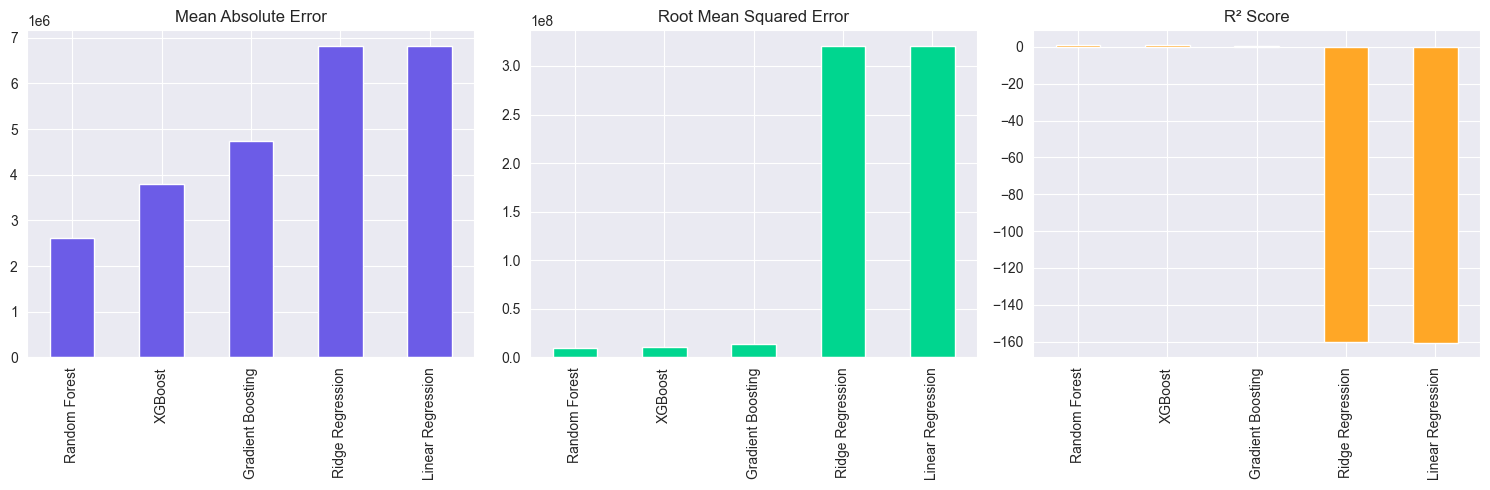

In [14]:
#  Model Comparison


results_df = pd.DataFrame(results).T
results_df = results_df[['MAE', 'RMSE', 'R²']]
results_df = results_df.sort_values('R²', ascending=False)

print("\n🏆 Model Performance Comparison:")
display(results_df)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
results_df['MAE'].plot(kind='bar', ax=axes[0], color='#6c5ce7')
axes[0].set_title('Mean Absolute Error')
results_df['RMSE'].plot(kind='bar', ax=axes[1], color='#00d68f')
axes[1].set_title('Root Mean Squared Error')
results_df['R²'].plot(kind='bar', ax=axes[2], color='#ffa726')
axes[2].set_title('R² Score')
plt.tight_layout()
plt.show()

In [16]:
# ============================================
# Cell 11: Fast Hyperparameter Tuning
# ============================================

# Select best model from results
best_model_name = results_df.index[0]
print(f"🏆 Best Model: {best_model_name}")
print(f"   R² Score: {results_df.loc[best_model_name, 'R²']:.4f}")
print(f"   MAE: LKR {results_df.loc[best_model_name, 'MAE']:,.2f}")

# ============================================
# Lightweight parameter grids (FAST)
# ============================================

param_grids = {
    'Random Forest': {
        'model__n_estimators': [100, 200],        # 2 options
        'model__max_depth': [10, 20, None],       # 3 options
        'model__min_samples_split': [5, 10],      # 2 options
        # Total: 2 × 3 × 2 = 12 combos × 5 folds = 60 fits ✅
    },
    'XGBoost': {
        'model__n_estimators': [100, 200],         # 2 options
        'model__max_depth': [5, 7],                # 2 options
        'model__learning_rate': [0.05, 0.1],       # 2 options
        # Total: 2 × 2 × 2 = 8 combos × 5 folds = 40 fits ✅
    },
    'Gradient Boosting': {
        'model__n_estimators': [100, 200],         # 2 options
        'model__max_depth': [5, 7],                # 2 options
        'model__learning_rate': [0.05, 0.1],       # 2 options
        # Total: 2 × 2 × 2 = 8 combos × 5 folds = 40 fits ✅
    }
}

# ============================================
# Use RandomizedSearchCV for even faster results
# ============================================

from sklearn.model_selection import RandomizedSearchCV

if best_model_name in param_grids:
    param_grid = param_grids[best_model_name]
    model_to_tune = models[best_model_name]

    total_combos = np.prod([len(v) for v in param_grid.values()])
    n_iter = min(20, total_combos)  # Max 20 random combinations

    print(f"\n🔧 Tuning {best_model_name}...")
    print(f"   Parameters: {list(param_grid.keys())}")
    print(f"   Total possible: {total_combos} combinations")
    print(f"   Testing: {n_iter} random combinations × 5 folds = {n_iter * 5} fits")
    print(f"   ⏱️ Estimated time: 2-5 minutes")

    # Use RandomizedSearchCV (faster than GridSearchCV)
    random_search = RandomizedSearchCV(
        model_to_tune,
        param_grid,
        n_iter=n_iter,
        cv=3,                    # 3-fold instead of 5 (faster)
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    random_search.fit(X_train, y_train)

    print(f"\n✅ Best Parameters Found:")
    for param, value in random_search.best_params_.items():
        print(f"   {param} = {value}")
    print(f"\n✅ Best CV Score (MAE): LKR {-random_search.best_score_:,.2f}")

    # Set final model
    final_model = random_search.best_estimator_

else:
    print(f"\n⚠️ Using default {best_model_name}")
    final_model = models[best_model_name]

🏆 Best Model: Random Forest
   R² Score: 0.8614
   MAE: LKR 2,617,590.08

🔧 Tuning Random Forest...
   Parameters: ['model__n_estimators', 'model__max_depth', 'model__min_samples_split']
   Total possible: 12 combinations
   Testing: 12 random combinations × 5 folds = 60 fits
   ⏱️ Estimated time: 2-5 minutes
Fitting 3 folds for each of 12 candidates, totalling 36 fits


KeyboardInterrupt: 

In [18]:
# Quick Fix: Define final_model


# Get the best model name from results
best_model_name = results_df.index[0]

# Use the trained model from Cell 9
final_model = models[best_model_name]

print(f"✅ Final Model Set: {best_model_name}")
print(f"   R² Score: {results_df.loc[best_model_name, 'R²']:.4f}")
print(f"   MAE: LKR {results_df.loc[best_model_name, 'MAE']:,.2f}")

✅ Final Model Set: Random Forest
   R² Score: 0.8614
   MAE: LKR 2,617,590.08


🎯 Final Model Performance:
   MAE:  LKR 2,617,590.08
   RMSE: LKR 9,391,427.24
   R²:   0.8614


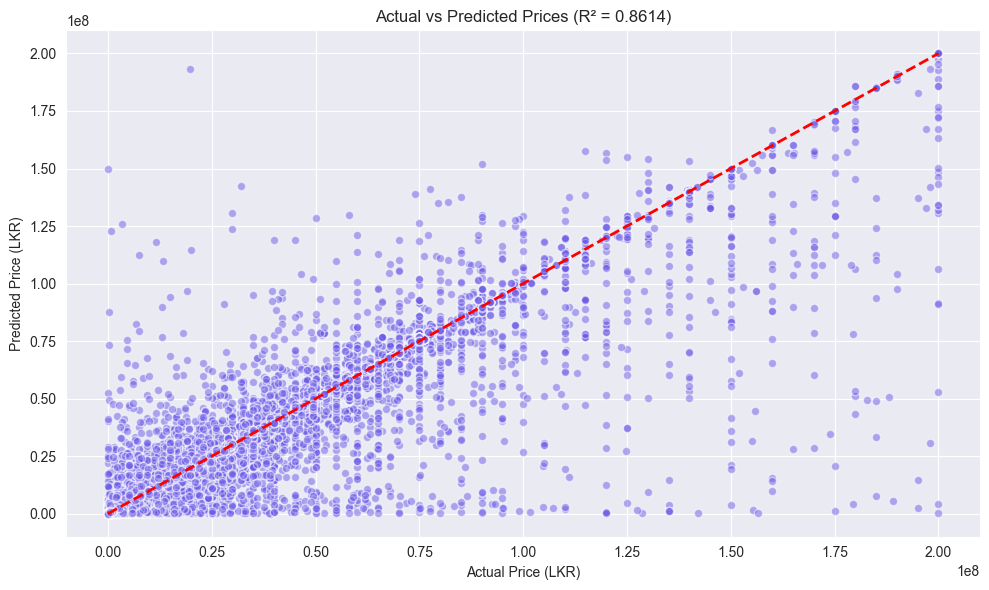

In [19]:
# Cell 12: Final Evaluation


y_pred_final = final_model.predict(X_test)
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_final)

# Final metrics
final_mae = mean_absolute_error(y_test_actual, y_pred_actual)
final_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
final_r2 = r2_score(y_test_actual, y_pred_actual)

print("🎯 Final Model Performance:")
print(f"   MAE:  LKR {final_mae:,.2f}")
print(f"   RMSE: LKR {final_rmse:,.2f}")
print(f"   R²:   {final_r2:.4f}")

# Actual vs Predicted plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5, c='#6c5ce7', edgecolors='white')
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()], 'r--', lw=2)
plt.xlabel('Actual Price (LKR)')
plt.ylabel('Predicted Price (LKR)')
plt.title(f'Actual vs Predicted Prices (R² = {final_r2:.4f})')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()